In [1]:
from pathlib import Path
import jax.numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# plt.rc('text', usetex=True)
# plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


## Injection

In [2]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [ ]:
n = 30
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space. We're using fixed R_orbit values
src_pos_array = np.geomspace(0.02, 0.99, n)
dL_array = np.geomspace(0.1, 10, n)
src_pos_mesh, dL_mesh = np.meshgrid(src_pos_array, dL_array, indexing='xy')
events['src_pos'] = src_pos_mesh
events['dL'] = dL_mesh

## Test plot SNR at fixed $R_{orbit}$

In [4]:
import numpy as onp

In [5]:
R_orbit_list = [20, 100, 1000]
events_list = []
for R_orbit in R_orbit_list:
    events_temp = events.copy()
    events_temp['R_orbit'] = np.full(shape, R_orbit)
    events_list.append(events_temp)

SNR_list = []
for events in events_list:
    SNR_temp = HLV_AGN.SNR(events)
    SNR_list.append(SNR_temp)

Text(0.5, 1.0, 'SNR for HLV Network at $R = 20 R_S$')

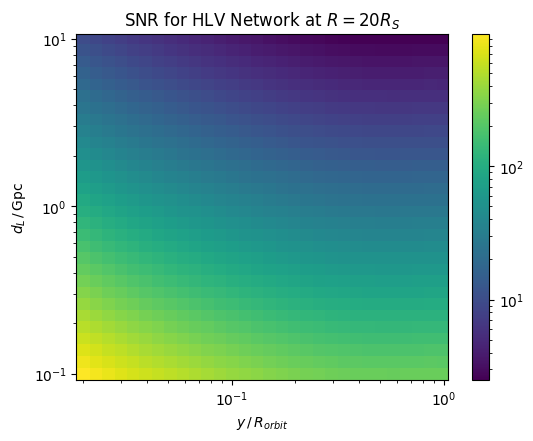

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
im = ax.pcolormesh(src_pos_array, dL_array, SNR_list[0], 
                   norm=LogNorm()
                   )
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$d_L\,/\,\mathrm{Gpc}$')
ax.set_xlabel(r'$y\,/\,R_{orbit}$')
ax.set_title(r'SNR for HLV Network at $R = {:} R_S$'.format(R_orbit_list[0]))

## SNR, $\Delta\iota$, and relative mass

In [7]:
general_event_params_list = []
delta_iota_list = []
relative_mass_list = []
for events in events_list:
    general_event_params = L1_AGN.convert_to_general_lensed_parameters(events)
    delta_iota = onp.asarray(general_event_params['delta_iota'])
    relative_mass = onp.asarray(general_event_params['relative_mass'])
    delta_iota_list.append(delta_iota)
    relative_mass_list.append(relative_mass)

Text(0.5, 0.98, 'SNR contours, $\\Delta\\iota$ and relative masses for HLV Network')

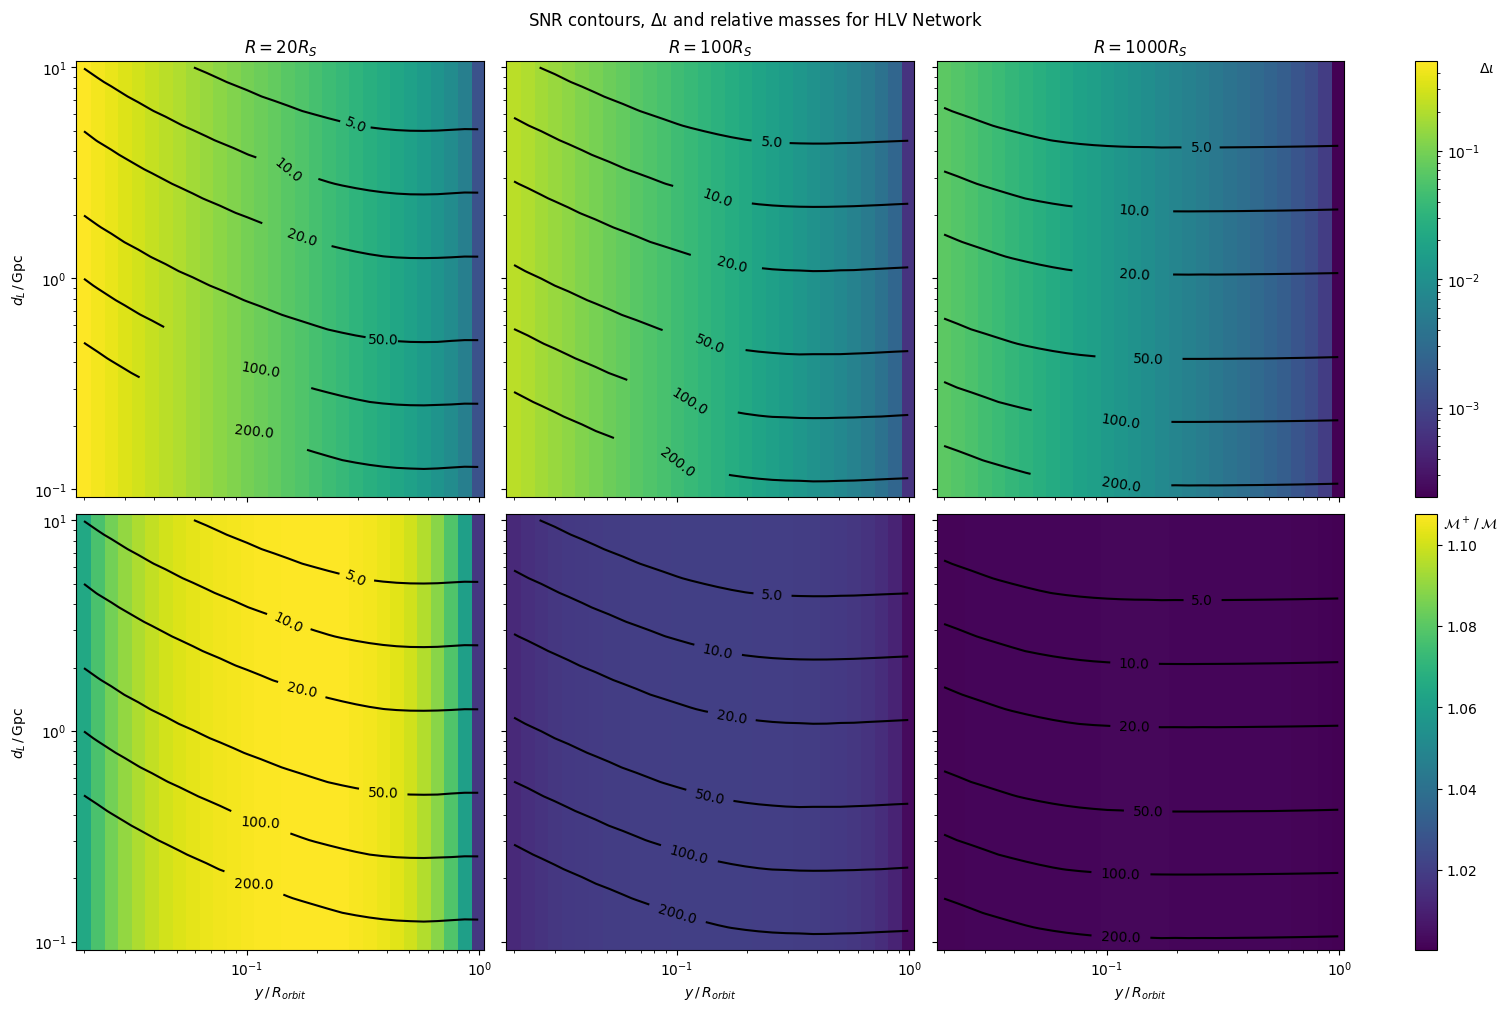

In [8]:
vmin0 = onp.nanmin(delta_iota_list)
vmax0 = onp.nanmax(delta_iota_list)
vmin1 = onp.nanmin(relative_mass_list)
vmax1 = onp.nanmax(relative_mass_list)

SNR_levels = [5, 10, 20, 50, 100, 200]

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex='col', sharey='row', constrained_layout=True)

im_list0 = []
for i in range(3):
    ax = axs[0, i]
    im = ax.pcolormesh(src_pos_array, dL_array, delta_iota_list[i],
                       norm=LogNorm(vmin=vmin0, vmax=vmax0)
                       )
    im_list0.append(im)
    contour = ax.contour(src_pos_array, dL_array, onp.asarray(SNR_list[i]), 
                         levels=SNR_levels, colors='black')
    ax.clabel(contour, fmt='%1.1f', colors='black')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(r'$R = {:} R_S$'.format(R_orbit_list[i]))

cbar_delta_iota = fig.colorbar(im_list0[0], ax=axs[0, :])
cbar_delta_iota.set_label(r'$\Delta\iota$', labelpad=10, loc='top', rotation=0)

im_list1 = []
for i in range(3):
    ax = axs[1, i]
    im = ax.pcolormesh(src_pos_array, dL_array, relative_mass_list[i], vmin=vmin1, vmax=vmax1,
                      #  norm=LogNorm()
                       )
    im_list1.append(im)
    contour = ax.contour(src_pos_array, dL_array, onp.asarray(SNR_list[i]), 
                         levels=SNR_levels, colors='black')
    ax.clabel(contour, fmt='%1.1f', colors='black')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$y\,/\,R_{orbit}$')

cbar_relative_mass = fig.colorbar(im_list1[0], ax=axs[1, :])
cbar_relative_mass.set_label(r'$\mathcal{M}^+\,/\,\mathcal{M}$', labelpad=15, loc='top', rotation=0)

axs[0, 0].set_ylabel(r'$d_L\,/\,\mathrm{Gpc}$')
axs[1, 0].set_ylabel(r'$d_L\,/\,\mathrm{Gpc}$')
fig.suptitle('SNR contours, $\Delta\iota$ and relative masses for HLV Network')